In [1]:
# %% [markdown]
# # K-means Clustering 
# 

# %%
# Importing Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# %%
df=pd.read_csv('Live.csv')

# %%
df.head()

# %%
df.isnull().sum()

# %%
df.shape

# %%
df1=df.drop(columns=['Column1','Column2','Column3','Column4'],axis=1)

# %%
df1.duplicated().sum()

# %%
df_clean=df1.drop_duplicates()

# %%
df_clean.duplicated().count()

# %%
df_clean.describe()

# %%
df_clean.info()

# %%
df_clean['status_id'].unique().__len__()

# %%
df_clean.head()

# %%
df_clean['status_type'].unique().__len__()

# %%
df_clean=df_clean.drop(columns=['status_id','status_published'],axis=1)

# %%
df_clean.head()

# %%
df_clean.info()

# %%
df.shape

# %%
df_clean.duplicated().sum()

# %%
df_clean=df_clean.drop_duplicates()

# %%
x=df_clean
y=df_clean['status_type']

# %%
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
x['status_type']= le.fit_transform(x['status_type'])
y=le.transform(y)

# %%
# After fitting the encoder, check the classes_ attribute
print(le.classes_)

# %%
x.info()

# %%
x.head()

# %%
cols=x.columns


# %%
from sklearn.preprocessing import MinMaxScaler
ms = MinMaxScaler()      # 1. Create the scaler object
x = ms.fit_transform(x)  # 2. Fit it to your data AND transform the data in one step

# %%
x

# %%
from sklearn.cluster import KMeans
kmeans= KMeans(n_clusters=2,random_state=0)
kmeans.fit(x)

# %%
x=pd.DataFrame(x,columns=[cols])

# %%
x.head()

# %%
kmeans.inertia_

# %%

<class 'pandas.core.frame.DataFrame'>
Index: 6999 entries, 0 to 7049
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   status_id         6999 non-null   object
 1   status_type       6999 non-null   object
 2   status_published  6999 non-null   object
 3   num_reactions     6999 non-null   int64 
 4   num_comments      6999 non-null   int64 
 5   num_shares        6999 non-null   int64 
 6   num_likes         6999 non-null   int64 
 7   num_loves         6999 non-null   int64 
 8   num_wows          6999 non-null   int64 
 9   num_hahas         6999 non-null   int64 
 10  num_sads          6999 non-null   int64 
 11  num_angrys        6999 non-null   int64 
dtypes: int64(9), object(3)
memory usage: 710.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 6999 entries, 0 to 7049
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   status_ty

216.44959979988036

In [9]:
cols=x.columns

In [7]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4987 entries, 0 to 4986
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (status_type,)    4987 non-null   float64
 1   (num_reactions,)  4987 non-null   float64
 2   (num_comments,)   4987 non-null   float64
 3   (num_shares,)     4987 non-null   float64
 4   (num_likes,)      4987 non-null   float64
 5   (num_loves,)      4987 non-null   float64
 6   (num_wows,)       4987 non-null   float64
 7   (num_hahas,)      4987 non-null   float64
 8   (num_sads,)       4987 non-null   float64
 9   (num_angrys,)     4987 non-null   float64
dtypes: float64(10)
memory usage: 389.7 KB


In [8]:
x.head()

,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,1.000000,0.112314,0.024393,0.076519,0.091720,0.140030,0.010791,0.006369,0.019608,0.0
1,0.333333,0.031847,0.000000,0.000000,0.031847,0.000000,0.000000,0.000000,0.000000,0.0
2,1.000000,0.048195,0.011243,0.016647,0.043312,0.031963,0.003597,0.006369,0.000000,0.0
3,0.333333,0.023567,0.000000,0.000000,0.023567,0.000000,0.000000,0.000000,0.000000,0.0
4,0.333333,0.045223,0.000000,0.000000,0.043312,0.013699,0.000000,0.000000,0.000000,0.0


In [6]:
print(le.classes_)

['link' 'photo' 'status' 'video']


In [ ]:
df_clean.head()

array([3, 1, 3, ..., 1, 1, 1], shape=(4987,))

In [2]:
kmeans.cluster_centers_

array([[1.        , 0.07482253, 0.0382231 , 0.04218374, 0.06411617,
        0.06752974, 0.01099153, 0.01380213, 0.01013439, 0.0102349 ],
       [0.36444302, 0.0602732 , 0.00118256, 0.00108589, 0.05952479,
        0.00305341, 0.00351752, 0.00170369, 0.00416305, 0.00184154]])

In [3]:
labels=kmeans.labels_
correct_labels=sum(y==labels)
print("result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))

result: 2707 out of 4987 samples were correctly labeled.


In [5]:
print("accuracy score:{0:0.2f}".format(correct_labels/y.size))

accuracy score:0.54


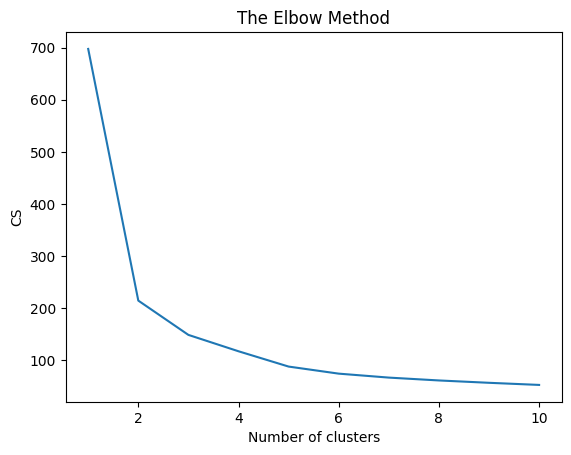

In [6]:
from sklearn.cluster import KMeans
cs=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',max_iter=300,n_init=10,random_state=0)
    kmeans.fit(x)
    cs.append(kmeans.inertia_)
plt.plot(range(1,11),cs)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('CS')
plt.show()

In [20]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=0)
kmeans.fit(x)
x=pd.DataFrame(x,columns=[cols])

# %%
x.head()

# %%
kmeans.inertia_
kmeans.cluster_centers_
labels=kmeans.labels_
correct_labels=sum(y==labels)
print("result: %d out of %d samples were correctly labeled." % (correct_labels, y.size))
print("accuracy score:{0:0.2f}".format(correct_labels/y.size))

result: 2517 out of 4987 samples were correctly labeled.
accuracy score:0.50
